# Logistic Regression from Scratch with PyTorch

In [1]:
import numpy as np
import torch

from sklearn import compose, datasets, linear_model, metrics, model_selection
from sklearn import pipeline, preprocessing

## Load the CovType dataset

In [2]:
covtype_dataset = datasets.fetch_covtype(
    as_frame=True
)

In [3]:
print(covtype_dataset["DESCR"])

.. _covtype_dataset:

Forest covertypes
-----------------

The samples in this dataset correspond to 30×30m patches of forest in the US,
collected for the task of predicting each patch's cover type,
i.e. the dominant species of tree.
There are seven covertypes, making this a multiclass classification problem.
Each sample has 54 features, described on the
`dataset's homepage <https://archive.ics.uci.edu/ml/datasets/Covertype>`__.
Some of the features are boolean indicators,
while others are discrete or continuous measurements.

**Data Set Characteristics:**

=================   ============
Classes                        7
Samples total             581012
Dimensionality                54
Features                     int
=================   ============

:func:`sklearn.datasets.fetch_covtype` will load the covertype dataset;
it returns a dictionary-like 'Bunch' object
with the feature matrix in the ``data`` member
and the target values in ``target``. If optional argument 'as_frame' is
se

In [4]:
covtype_features_df = covtype_dataset["data"]
covtype_target_df = (
    covtype_dataset.get("target")
                   .to_frame()
)

In [5]:
covtype_features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 54 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Elevation                           581012 non-null  float64
 1   Aspect                              581012 non-null  float64
 2   Slope                               581012 non-null  float64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  float64
 4   Vertical_Distance_To_Hydrology      581012 non-null  float64
 5   Horizontal_Distance_To_Roadways     581012 non-null  float64
 6   Hillshade_9am                       581012 non-null  float64
 7   Hillshade_Noon                      581012 non-null  float64
 8   Hillshade_3pm                       581012 non-null  float64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  float64
 10  Wilderness_Area_0                   581012 non-null  float64
 11  Wilderness_Area_1         

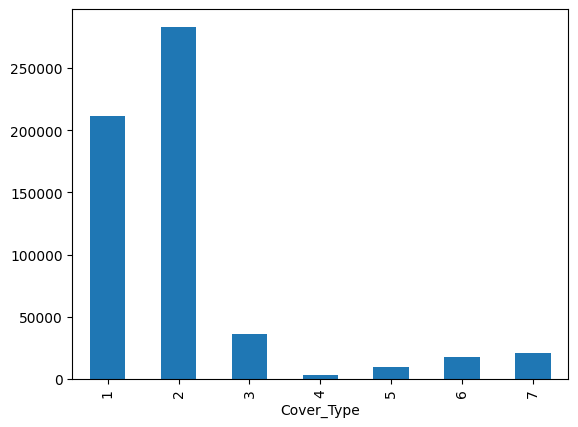

In [6]:
_ = (
    covtype_target_df.loc[:, "Cover_Type"]
                     .value_counts()
                     .sort_index()
                     .plot(kind="bar")
)

## Train/Val Split

In [47]:
RANDOM_STATE = np.random.RandomState(42)


train_features_df, val_features_df, train_target_df, val_target_df = (
    model_selection.train_test_split(
        covtype_features_df,
        covtype_target_df,
        test_size=0.20,
        shuffle=True,
        stratify=covtype_target_df,
        random_state=RANDOM_STATE
    )
)


In [48]:
train_features_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 464809 entries, 261834 to 52912
Data columns (total 54 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Elevation                           464809 non-null  float64
 1   Aspect                              464809 non-null  float64
 2   Slope                               464809 non-null  float64
 3   Horizontal_Distance_To_Hydrology    464809 non-null  float64
 4   Vertical_Distance_To_Hydrology      464809 non-null  float64
 5   Horizontal_Distance_To_Roadways     464809 non-null  float64
 6   Hillshade_9am                       464809 non-null  float64
 7   Hillshade_Noon                      464809 non-null  float64
 8   Hillshade_3pm                       464809 non-null  float64
 9   Horizontal_Distance_To_Fire_Points  464809 non-null  float64
 10  Wilderness_Area_0                   464809 non-null  float64
 11  Wilderness_Area_1          

In [49]:
val_features_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 116203 entries, 438215 to 287422
Data columns (total 54 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Elevation                           116203 non-null  float64
 1   Aspect                              116203 non-null  float64
 2   Slope                               116203 non-null  float64
 3   Horizontal_Distance_To_Hydrology    116203 non-null  float64
 4   Vertical_Distance_To_Hydrology      116203 non-null  float64
 5   Horizontal_Distance_To_Roadways     116203 non-null  float64
 6   Hillshade_9am                       116203 non-null  float64
 7   Hillshade_Noon                      116203 non-null  float64
 8   Hillshade_3pm                       116203 non-null  float64
 9   Horizontal_Distance_To_Fire_Points  116203 non-null  float64
 10  Wilderness_Area_0                   116203 non-null  float64
 11  Wilderness_Area_1         

## Prepare the data

In [50]:
def array_to_tensor(arr, dtype=torch.float32):
  return torch.tensor(arr, dtype=dtype)


prepare_covtype_features = pipeline.make_pipeline(
    compose.make_column_transformer(
        (
            "passthrough",
            compose.make_column_selector(
                pattern="^Wilderness_Area_|^Soil_Type_"
            )
        ),
        force_int_remainder_cols=False,
        n_jobs=-1,
        remainder=preprocessing.QuantileTransformer(
            output_distribution="normal",
            random_state=RANDOM_STATE,
        )
    ),
    preprocessing.FunctionTransformer(
        func=array_to_tensor,
    )
)

prepare_covtype_target = pipeline.make_pipeline(
    preprocessing.OrdinalEncoder(
        categories=[
            [1, 2, 3, 4, 5, 6, 7]
        ],
    ),
    preprocessing.FunctionTransformer(
        func=array_to_tensor,
        kw_args={
            "dtype": torch.int64
        }
    ),
    preprocessing.FunctionTransformer(
        func=torch.squeeze,
    )
)



In [51]:
X_train = prepare_covtype_features.fit_transform(train_features_df)
X_val = prepare_covtype_features.transform(val_features_df)


In [52]:
print(X_train.shape)
print(X_val.shape)

torch.Size([464809, 54])
torch.Size([116203, 54])


In [53]:
y_train = prepare_covtype_target.fit_transform(train_target_df)
y_val = prepare_covtype_target.transform(val_target_df)


In [54]:
print(y_train.shape)
print(y_train.dtype)

print(y_val.shape)
print(y_val.dtype)

torch.Size([464809])
torch.int64
torch.Size([116203])
torch.int64


## Logistic Regression using Tensors

### Initialize parameters

In [55]:
prng = torch.manual_seed(42)

n_features = X_train.size(1)
n_classes = y_train.unique().size(0)

weights = torch.randn((n_features, n_classes), requires_grad=True)
bias = torch.zeros(1, n_classes, requires_grad=True)

In [56]:
print(weights.shape)
print(bias.shape)

torch.Size([54, 7])
torch.Size([1, 7])


### Define our model and loss functions

In [57]:
def model_fn(X):
    return X @ weights + bias


def softmax_activation_fn(y_pred):
    return torch.exp(y_pred) / torch.sum(torch.exp(y_pred), dim=1, keepdim=True)


def log_softmax_activation_fn(y_pred):
    return torch.log(softmax_activation_fn(y_pred))


def neg_log_likelihood_loss_fn(log_probas_pred, y_true):
    batch_indicies = torch.arange(y_true.size(0))
    target_indices = y_true
    return -torch.mean(log_probas_pred[batch_indicies, target_indices])


def loss_fn(y_pred, y_true):
    log_probas_pred = log_softmax_activation_fn(y_pred)
    return neg_log_likelihood_loss_fn(log_probas_pred, y_true)



### Training using full batch gradient descent

In [58]:
learning_rate = 0.5
n_epochs = 100

for epoch in range(n_epochs):
    # forward pass
    y_pred = model_fn(X_train)
    train_loss = loss_fn(y_pred, y_train)

    # backward pass
    train_loss.backward()

    # gradient descent step
    with torch.no_grad():
        bias -= learning_rate * bias.grad
        weights -= learning_rate * weights.grad
        bias.grad.zero_()
        weights.grad.zero_()

    # evaluate using the validation data
    with torch.no_grad():
        y_pred = model_fn(X_val)
        val_loss = loss_fn(y_pred, y_val)

    print(f"Epoch {epoch + 1}/{n_epochs}, Training Loss: {train_loss.item(): .4f}, Val Loss: {val_loss.item(): .4f}")



Epoch 1/100, Training Loss:  4.2573, Val Loss:  3.9279
Epoch 2/100, Training Loss:  3.9292, Val Loss:  3.6218
Epoch 3/100, Training Loss:  3.6229, Val Loss:  3.3376
Epoch 4/100, Training Loss:  3.3386, Val Loss:  3.0754
Epoch 5/100, Training Loss:  3.0761, Val Loss:  2.8351
Epoch 6/100, Training Loss:  2.8355, Val Loss:  2.6162
Epoch 7/100, Training Loss:  2.6162, Val Loss:  2.4182
Epoch 8/100, Training Loss:  2.4178, Val Loss:  2.2405
Epoch 9/100, Training Loss:  2.2396, Val Loss:  2.0821
Epoch 10/100, Training Loss:  2.0809, Val Loss:  1.9420
Epoch 11/100, Training Loss:  1.9404, Val Loss:  1.8190
Epoch 12/100, Training Loss:  1.8170, Val Loss:  1.7117
Epoch 13/100, Training Loss:  1.7094, Val Loss:  1.6187
Epoch 14/100, Training Loss:  1.6161, Val Loss:  1.5383
Epoch 15/100, Training Loss:  1.5354, Val Loss:  1.4689
Epoch 16/100, Training Loss:  1.4659, Val Loss:  1.4091
Epoch 17/100, Training Loss:  1.4059, Val Loss:  1.3574
Epoch 18/100, Training Loss:  1.3541, Val Loss:  1.3126
E

## Logistic Regression using the Neural Network API

In [59]:
from torch import nn, optim

### Define our model and loss functions, and our optimizer

In [60]:
_ = torch.manual_seed(42)

# logistic regression only has a single layer
covtype_model = nn.Linear(
    in_features=n_features,
    out_features=n_classes,
    bias=True,
)

# using the cross entropy loss
cross_entropy_loss = nn.CrossEntropyLoss()

# define our optimizer
learning_rate = 0.5
sgd = optim.SGD(
    covtype_model.parameters(),
    lr=learning_rate
)

### Training using full batch gradient descent

In [61]:
def train(
    model_fn,
    criterion,
    optimizer,
    X_train,
    y_train,
    X_val,
    y_val,
    n_epochs
    ):

    for epoch in range(n_epochs):
        # forward pass
        y_pred = model_fn(X_train)
        train_loss = criterion(y_pred, y_train)

        # backward pass
        train_loss.backward()

        # gradient descent step
        optimizer.step()
        optimizer.zero_grad()

        # evaluate using the validation data
        with torch.no_grad():
            y_pred = model_fn(X_val)
            val_loss = criterion(y_pred, y_val)

        print(f"Epoch {epoch + 1}/{n_epochs}, Training Loss: {train_loss.item(): .4f}, Val Loss: {val_loss.item(): .4f}")


In [62]:
train(
    covtype_model,
    cross_entropy_loss,
    sgd,
    X_train,
    y_train,
    X_val,
    y_val,
    n_epochs=100
)

Epoch 1/100, Training Loss:  1.9818, Val Loss:  1.7429
Epoch 2/100, Training Loss:  1.7426, Val Loss:  1.5572
Epoch 3/100, Training Loss:  1.5564, Val Loss:  1.4155
Epoch 4/100, Training Loss:  1.4144, Val Loss:  1.3086
Epoch 5/100, Training Loss:  1.3072, Val Loss:  1.2279
Epoch 6/100, Training Loss:  1.2263, Val Loss:  1.1665
Epoch 7/100, Training Loss:  1.1647, Val Loss:  1.1191
Epoch 8/100, Training Loss:  1.1172, Val Loss:  1.0819
Epoch 9/100, Training Loss:  1.0799, Val Loss:  1.0522
Epoch 10/100, Training Loss:  1.0501, Val Loss:  1.0279
Epoch 11/100, Training Loss:  1.0258, Val Loss:  1.0077
Epoch 12/100, Training Loss:  1.0056, Val Loss:  0.9907
Epoch 13/100, Training Loss:  0.9886, Val Loss:  0.9761
Epoch 14/100, Training Loss:  0.9739, Val Loss:  0.9635
Epoch 15/100, Training Loss:  0.9612, Val Loss:  0.9523
Epoch 16/100, Training Loss:  0.9500, Val Loss:  0.9423
Epoch 17/100, Training Loss:  0.9400, Val Loss:  0.9334
Epoch 18/100, Training Loss:  0.9311, Val Loss:  0.9253
E

### Compare results with Scikit-Learn SGDClassifier

In [72]:
sgd_classifier = pipeline.make_pipeline(
    prepare_covtype_features[:-1],
    linear_model.SGDClassifier(
        learning_rate="constant",
        eta0=learning_rate,
        loss="log_loss",
        max_iter=100,
        n_jobs=-1,
        penalty=None,
        random_state=RANDOM_STATE,
    )
)

train_target = train_target_df.loc[:, "Cover_Type"]
_ = sgd_classifier.fit(train_features_df, train_target)

In [73]:
train_prediction = sgd_classifier.predict_proba(train_features_df)
train_log_loss = metrics.log_loss(
    train_target,
    train_prediction
)


val_target = val_target_df.loc[:, "Cover_Type"]
val_prediction = sgd_classifier.predict_proba(val_features_df)
val_log_loss = metrics.log_loss(
    val_target,
    val_prediction
)

print(f"Training loss: {train_log_loss: .4f}, Validation loss: {val_log_loss: .4f}")

Training loss:  1.1998, Validation loss:  1.2073


## Exercise

Load the breast cancer dataset using the code in the cell below. Prepare the data and then train a logistic regression model using PyTorch Neural Network API.

In [74]:
breast_cancer_dataset = datasets.load_breast_cancer(
    as_frame=True,
)

In [75]:
print(breast_cancer_dataset["DESCR"])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [76]:
breast_cancer_features_df = breast_cancer_dataset["data"]
breast_cancer_target = breast_cancer_dataset["target"]

In [77]:
breast_cancer_features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [78]:
breast_cancer_features_df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


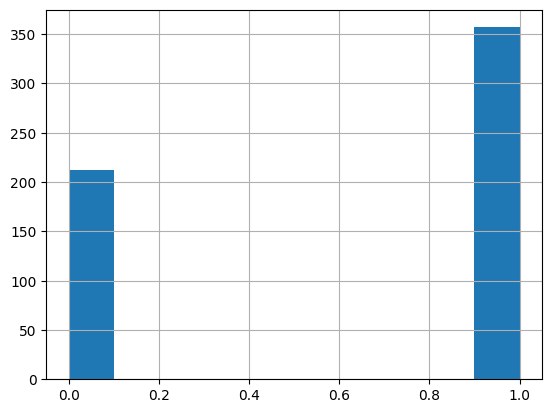

In [79]:
_ = breast_cancer_target.hist()

In [ ]:
# INSERT YOUR CODE HERE!

### Solution

In [80]:
train_features_df, val_features_df, train_target, val_target = (
    model_selection.train_test_split(
        breast_cancer_features_df,
        breast_cancer_target,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=breast_cancer_target,
        test_size=0.20,
    )
)


In [90]:
def dataframe_to_tensor(df, dtype=torch.float32):
    arr = df.to_numpy()
    return array_to_tensor(arr, dtype)


def series_to_tensor(s, dtype=torch.float32):
    df = s.to_frame()
    return dataframe_to_tensor(df, dtype)


n_samples, _ = train_features_df.shape
prepare_breast_cancer_features = pipeline.make_pipeline(
    preprocessing.QuantileTransformer(
      n_quantiles=n_samples,
      output_distribution="normal",
      random_state=RANDOM_STATE
    ),
    preprocessing.FunctionTransformer(
        func=array_to_tensor
    )
)

prepare_breast_cancer_target = pipeline.make_pipeline(
    preprocessing.FunctionTransformer(
        func=series_to_tensor,
        kw_args={
            "dtype": torch.int64
        }
    )
)

In [91]:
X_train = prepare_breast_cancer_features.fit_transform(train_features_df)
X_val = prepare_breast_cancer_features.transform(val_features_df)


In [92]:
print(X_train.shape)
print(X_val.shape)

torch.Size([455, 30])
torch.Size([114, 30])


In [93]:
y_train = prepare_breast_cancer_target.fit_transform(train_target)
y_val = prepare_breast_cancer_target.transform(val_target)


In [94]:
print(y_train.shape)
print(y_val.shape)

torch.Size([455])
torch.Size([114])


In [96]:
_ = torch.manual_seed(42)

# logistic regression only has a single layer
n_features = X_train.size(1)
n_classes = y_train.unique().size(0)

breast_cancer_model = nn.Linear(
    in_features=n_features,
    out_features=n_classes,
    bias=True,
)

# continue using the cross-entropy loss
cross_entropy_loss = nn.CrossEntropyLoss()

# define our optimizer
learning_rate = 1e-2
sgd = optim.SGD(
    breast_cancer_model.parameters(),
    lr=learning_rate
)

# train the model
train(
    breast_cancer_model,
    cross_entropy_loss,
    sgd,
    X_train,
    y_train,
    X_val,
    y_val,
    n_epochs=100
)

Epoch 1/100, Training Loss:  0.8833, Val Loss:  0.8542
Epoch 2/100, Training Loss:  0.8178, Val Loss:  0.8011
Epoch 3/100, Training Loss:  0.7602, Val Loss:  0.7547
Epoch 4/100, Training Loss:  0.7099, Val Loss:  0.7142
Epoch 5/100, Training Loss:  0.6661, Val Loss:  0.6787
Epoch 6/100, Training Loss:  0.6281, Val Loss:  0.6477
Epoch 7/100, Training Loss:  0.5951, Val Loss:  0.6203
Epoch 8/100, Training Loss:  0.5663, Val Loss:  0.5962
Epoch 9/100, Training Loss:  0.5412, Val Loss:  0.5747
Epoch 10/100, Training Loss:  0.5192, Val Loss:  0.5556
Epoch 11/100, Training Loss:  0.4998, Val Loss:  0.5384
Epoch 12/100, Training Loss:  0.4826, Val Loss:  0.5229
Epoch 13/100, Training Loss:  0.4673, Val Loss:  0.5088
Epoch 14/100, Training Loss:  0.4535, Val Loss:  0.4960
Epoch 15/100, Training Loss:  0.4411, Val Loss:  0.4843
Epoch 16/100, Training Loss:  0.4298, Val Loss:  0.4735
Epoch 17/100, Training Loss:  0.4196, Val Loss:  0.4635
Epoch 18/100, Training Loss:  0.4101, Val Loss:  0.4543
E

## Exercise (Optional)

Confirm that your results above are similar to those obtained using SGDRegressor from Scikit-Learn.


In [ ]:
# INSERT YOUR CODE HERE!

### Solution

In [99]:
sgd_classifier = pipeline.make_pipeline(
    prepare_breast_cancer_features[:-1],
    linear_model.SGDClassifier(
        learning_rate="constant",
        eta0=learning_rate,
        loss="log_loss",
        max_iter=100,
        n_jobs=-1,
        penalty=None,
        random_state=RANDOM_STATE,
    )
)

_ = sgd_classifier.fit(train_features_df, train_target)

In [100]:
train_prediction = sgd_classifier.predict_proba(train_features_df)
train_log_loss = metrics.log_loss(
    train_target,
    train_prediction
)


val_prediction = sgd_classifier.predict_proba(val_features_df)
val_log_loss = metrics.log_loss(
    val_target,
    val_prediction
)

print(f"Training loss: {train_log_loss: .4f}, Validation loss: {val_log_loss: .4f}")

Training loss:  0.0548, Validation loss:  0.1053
